In [ ]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)
path = "/content/drive/MyDrive/projet/"

In [2]:

import json

with open('../infos/test_videodatainfo.json', 'r') as file:
    data_test = json.load(file)

for key, item in data_test.items():
    print(key)

info
videos
sentences


In [3]:
# on doit fusionner les deux listes 'sentences' et 'videos' sur la clé 'video_id'

# données de Test

sentences = data_test['sentences']
videos = data_test['videos']

test = []

# dictionnaire selon identifiant de la video
dict_videos = {d['video_id']: d for d in videos}

for d1 in sentences:
    vid = d1['video_id']
    fusion_donnees = d1.copy()
    # Si on trouve le même video_id dans la 2e liste, on ajoute ses clés
    if vid in dict_videos:
        fusion_donnees.update(dict_videos[vid])
    # Ajout du résultat à la liste finale
    test.append(fusion_donnees)

In [4]:

with open('../infos/train_val_videodatainfo.json', 'r') as file:
    data_train = json.load(file)

In [5]:
# fusion des données de Train

sentences = data_train['sentences']
videos = data_train['videos']

train = []

dict_videos = {d['video_id']: d for d in videos}

for d1 in sentences:
    vid = d1['video_id']
    fusion_donnees = d1.copy()
    if vid in dict_videos:
        fusion_donnees.update(dict_videos[vid])
    train.append(fusion_donnees)

In [6]:
print(f"taille de train, {len(train)}, taille ddu test {len(test)}")

taille de train, 140200, taille ddu test 59800


Stat descriptives sur les données d'entrainement

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = train

# Conversion en DataFrame pandas
df = pd.DataFrame(data)

df.head()

,caption,video_id,sen_id,category,url,start time,end time,split,id
0,a cartoon animals runs through an ice cave in ...,video2960,0,2,https://www.youtube.com/watch?v=2nQWv233XrM,318.16,330.48,train,2960
1,a cartoon character runs around inside of a vi...,video2960,1,2,https://www.youtube.com/watch?v=2nQWv233XrM,318.16,330.48,train,2960
2,a character is running in the snow,video2960,2,2,https://www.youtube.com/watch?v=2nQWv233XrM,318.16,330.48,train,2960
3,a person plays a video game centered around ic...,video2960,3,2,https://www.youtube.com/watch?v=2nQWv233XrM,318.16,330.48,train,2960
4,a person plays online and records themselves,video2960,4,2,https://www.youtube.com/watch?v=2nQWv233XrM,318.16,330.48,train,2960


In [8]:
# Nombre total de captions
nb_captions = len(df)

# Nombre total de vidéos
nb_videos = df['video_id'].nunique()

# Nombre de catégories
nb_categories = df['category'].nunique()

print(f"Nombre total de captions : {nb_captions}")
print(f"Nombre total de vidéos : {nb_videos}")
print(f"Nombre de catégories : {nb_categories}")


Nombre total de captions : 140200
Nombre total de vidéos : 7010
Nombre de catégories : 20


In [9]:
captions_par_video = df.groupby('video_id').size()
print(f"Nombre moyen de captions par vidéo : {captions_par_video.mean()}")
print(f"Min: {captions_par_video.min()}, Max: {captions_par_video.max()}")


Nombre moyen de captions par vidéo : 20.0
Min: 20, Max: 20


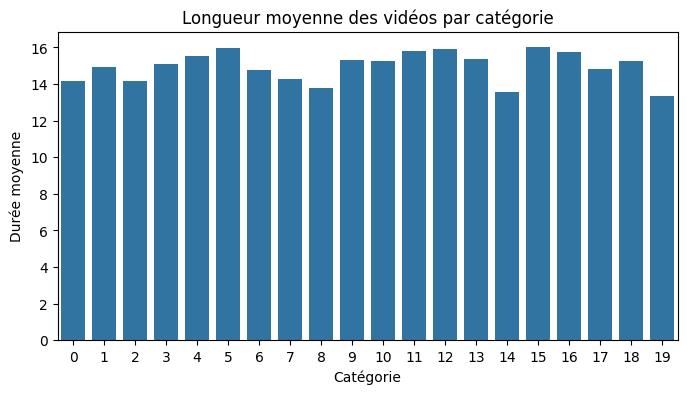

In [10]:
df['video_length'] = df['end time'] - df['start time']

mean_length_video = df.groupby('category')['video_length'].mean()

plt.figure(figsize=(8,4))
sns.barplot(x=mean_length_video.index, y=mean_length_video.values)
plt.title("Longueur moyenne des vidéos par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Durée moyenne")
plt.show()


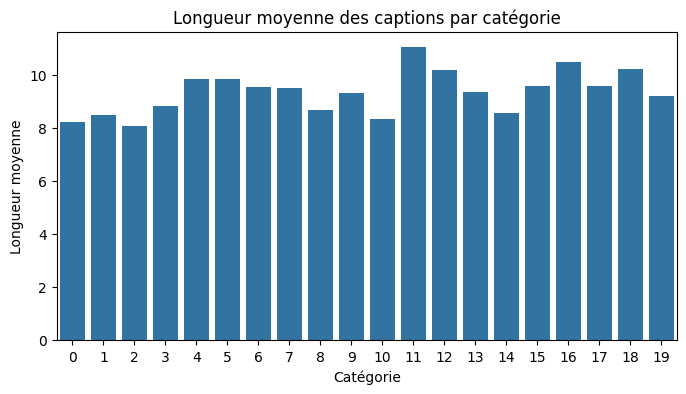

In [11]:
df['caption_length'] = df['caption'].apply(lambda x: len(x.split()))

mean_length_caption = df.groupby('category')['caption_length'].mean()

plt.figure(figsize=(8,4))
sns.barplot(x=mean_length_caption.index, y=mean_length_caption.values)
plt.title("Longueur moyenne des captions par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Longueur moyenne")
plt.show()


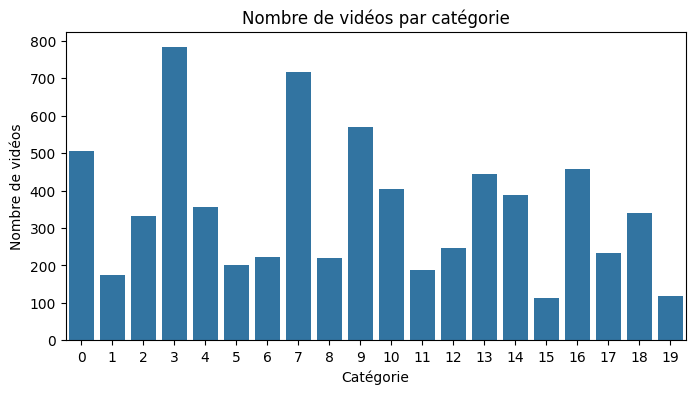

In [12]:
videos_par_category = df.groupby('category')['video_id'].nunique()

plt.figure(figsize=(8,4))
sns.barplot(x=videos_par_category.index, y=videos_par_category.values)
plt.title("Nombre de vidéos par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de vidéos")
plt.show()

Séparation en train, val

In [13]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    train,
    test_size=0.2,
    stratify=[d["category"] for d in train],
    random_state=42
)

print(f"Taille train: {len(train_data)}, validation: {len(val_data)}")
train, val = train_data, val_data

Taille train: 112160, validation: 28040


### Preparation des données

In [14]:
from torch.utils.data import Dataset, DataLoader

class VideoCaptionDataset(Dataset):
    def __init__(self, data):
        self.captions = [item['caption'] for item in data]
        self.labels = [item['category'] for item in data]

    def __len__(self):
        return len(self.captions)

    def __getitem__(self, idx):
        return {
            'text': self.captions[idx],
            'label': self.labels[idx]
        }

train_dataset = VideoCaptionDataset(train)
val_dataset = VideoCaptionDataset(val)
test_dataset = VideoCaptionDataset(test)

### Tokenization

In [15]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def collate_fn(batch):
    texts = [x['text'] for x in batch]
    labels = [x['label'] for x in batch]
    encodings = tokenizer(texts, truncation=True, padding=True, return_tensors="pt")
    encodings['labels'] = torch.tensor(labels)
    return encodings

Modele

In [16]:
import torch
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, vocab_size, output_dim,
                 n_layers=4, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout
        )

        self.batch_norm = nn.BatchNorm1d(hidden_dim)

        self.fc1 = nn.Linear(hidden_dim, 512)
        self.fc2 = nn.Linear(512, 560)
        self.fc3 = nn.Linear(560, 512)
        self.fc4 = nn.Linear(512, output_dim)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        hidden = hidden[-1]  # dernière couche du LSTM

        hidden = self.batch_norm(hidden)
        hidden = self.dropout(hidden)
        hidden = self.relu(self.fc1(hidden))
        hidden = self.dropout(hidden)
        hidden = self.relu(self.fc2(hidden))
        hidden = self.dropout(hidden)
        hidden = self.relu(self.fc3(hidden))
        hidden = self.dropout(hidden)
        out = self.fc4(hidden)

        return out

Boucle d'entrainement

In [17]:
tokenizer.vocab_size

30522

In [ ]:
import torch.optim as optim
import torch.nn.functional as F
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

model = LSTMClassifier(
    embedding_dim=218,
    hidden_dim=560,
    vocab_size=tokenizer.vocab_size,
    output_dim=20,
    n_layers=4,
    dropout=0.5
).to(device)

optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=2e-4)

# Scheduler adaptatif basé sur la validation
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2)

save_path = "best_model.pt"

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

best_val_loss = 1000

liste_train_acc = []
liste_train_loss = []
liste_val_acc = []
liste_val_loss = []

for epoch in range(20):
    model.train()
    train_loss = 0
    correct_train = 0
    total_train = 0

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids)
        loss = F.cross_entropy(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss /= len(train_loader)
    train_accuracy = correct_train / total_train

    # Validation
    model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids)
            loss = F.cross_entropy(outputs, labels)
            val_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss /= len(val_loader)
    val_accuracy = correct_val / total_val

    print(f"Epoch {epoch+1} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")
    liste_train_acc.append(train_accuracy)
    liste_train_loss.append(train_loss)
    liste_val_acc.append(val_accuracy)
    liste_val_loss.append(val_loss)

    # Sauvegarde du meilleur modèle
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), save_path)
        print("=> Best model saved")

    # Scheduler
    scheduler.step(val_loss)

Courbe d'apprentissage

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

epoch = np.arange(1,21)

#Historique du Loss

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(liste_train_loss, label="Train Loss")
plt.plot(liste_val_loss, label="Test Loss")
plt.title("Training et Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Historique de l'accuracy
plt.subplot(1, 2, 2)
plt.plot(liste_train_acc, label="Train Accuracy")
plt.plot(liste_val_acc, label="Test Accuracy")
plt.title("Training et Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()